In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv('train (1).csv')
print("Shape:", df.shape)
print(df.head())
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))
print("\nSalePrice stats:")
print(df['SalePrice'].describe())


Shape: (1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0  

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Select only 9 columns from already loaded df
cols = ['GrLivArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF',
        'GarageCars', 'FullBath', 'BedroomAbvGr', 'LotArea', 'SalePrice']

df = df[cols]
print("Shape:", df.shape)
print(df.head())

Shape: (1460, 9)
   GrLivArea  OverallQual  YearBuilt  TotalBsmtSF  GarageCars  FullBath  \
0       1710            7       2003          856           2         2   
1       1262            6       1976         1262           2         2   
2       1786            7       2001          920           2         2   
3       1717            7       1915          756           3         1   
4       2198            8       2000         1145           3         2   

   BedroomAbvGr  LotArea  SalePrice  
0             3     8450     208500  
1             3     9600     181500  
2             3    11250     223500  
3             3     9550     140000  
4             4    14260     250000  


In [ ]:
print("Missing values:")
print(df.isnull().sum())
df.fillna(df.median(), inplace=True)
print("\nAfter cleaning - missing values:")
print(df.isnull().sum())

Missing values:
GrLivArea       0
OverallQual     0
YearBuilt       0
TotalBsmtSF     0
GarageCars      0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64

After cleaning - missing values:
GrLivArea       0
OverallQual     0
YearBuilt       0
TotalBsmtSF     0
GarageCars      0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64


In [ ]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 1168
Testing rows: 292


In [ ]:

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)


rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Linear Regression → RMSE:", round(lr_rmse), "| R²:", round(lr_r2, 2))
print("Random Forest     → RMSE:", round(rf_rmse), "| R²:", round(rf_r2, 2))

Linear Regression → RMSE: 38877 | R²: 0.8
Random Forest     → RMSE: 28552 | R²: 0.89


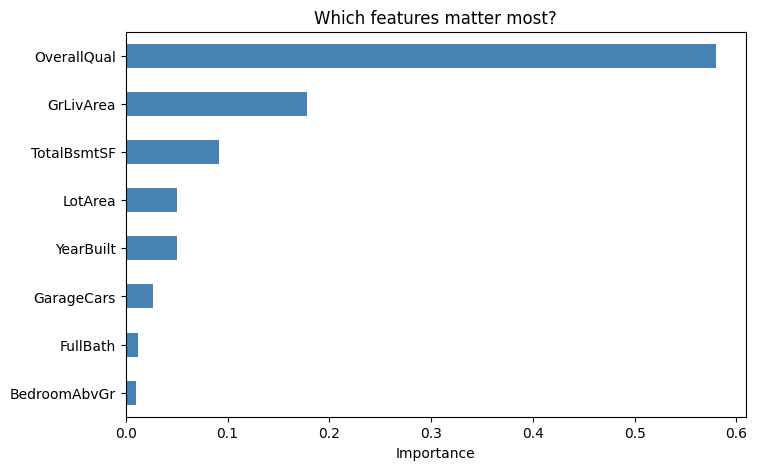

In [ ]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8,5), color='steelblue')
plt.title('Which features matter most?')
plt.xlabel('Importance')
plt.show()